# Linear Pendulum Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the pendulum Oscillator system using the multi-trajectory (Part 1) workflow.

## Governing Equations

The damped linear pendulum dynamics are

$$
\begin{align*}
\dot{\theta} &= \omega, \\
\dot{\omega} &= -\frac{b}{m}\omega - \frac{g}{L}\theta,
\end{align*}
$$

where $\theta$ is the angular displacement, $\omega$ is the angular velocity, $b$ is the damping coefficient, $m$ is the mass, $g$ is the gravitational acceleration, and $L$ is the pendulum length.

We use parameters $\left(\frac{b}{m}, \frac{g}{L}\right)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.pendulum import (
    PendulumMultiTrajectoryGLSConfig,
    generate_pendulum_dataset,
    run_pendulum_multi_trajectory_gls_experiment,
)
from mfsindy.cases.pendulum_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]


In [ ]:
cfg = PendulumMultiTrajectoryGLSConfig(
    n_runs=25,
    results_dir=str(RESULTS_DIR),
    results_filename="pendulum_part1_errors.csv",
    stlsq_threshold=0.1,
    T_true=10.0,
    T_train=0.1,
    n_hf=10,
    n_lf=100,
    c=0.5,
    L=1.0,
)

print(
    f"Running Part 1 pendulum experiment with n_LF={cfg.n_lf}, n_HF={cfg.n_hf}, "
    f"noise_rel(LF)={cfg.noise_lf_rel}, noise_rel(HF)={cfg.noise_hf_rel}."
)

(
    _,
    _,
    _,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_pendulum_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)



Running Part 1 pendulum experiment with n_LF=100, n_HF=10, noise_rel(LF)=0.25, noise_rel(HF)=0.01.


Monte Carlo pendulum MF:   0%|          | 0/25 [00:00<?, ?it/s]

MODEL HF:
(x0)' =  0.987 x1
(x1)' = -9.773 x0 + -0.518 x1
MODEL LF:
(x0)' =  1.097 x1
(x1)' = -9.650 x0 + -0.518 x1
MODEL MF:
(x0)' =  1.109 x1
(x1)' = -9.620 x0 + -0.545 x1


Monte Carlo pendulum MF:   4%|▍         | 1/25 [00:04<01:54,  4.75s/it]

MODEL MFW:
(x0)' =  0.991 x1
(x1)' = -9.763 x0 + -0.514 x1
MODEL HF:
(x0)' =  0.000
(x1)' = -9.761 x0 + -0.523 x1
MODEL LF:
(x0)' = -0.058 x0 +  0.903 x1
(x1)' = -9.893 x0 + -0.106 x1
MODEL MF:
(x0)' = -0.075 x0 +  0.938 x1
(x1)' = -9.946 x0 + -0.172 x1


...

MODEL MFW:
(x0)' =  1.000 x1
(x1)' = -9.785 x0 + -0.486 x1
MODEL HF:
(x0)' =  0.000
(x1)' = -9.787 x0
MODEL LF:
(x0)' =  1.114 x1
(x1)' = -9.724 x0 + -0.485 x1
MODEL MF:
(x0)' =  1.058 x1
(x1)' = -9.729 x0 + -0.482 x1


Monte Carlo pendulum MF:  52%|█████▏    | 13/25 [01:02<00:58,  4.86s/it]

MODEL MFW:
(x0)' =  1.000 x1
(x1)' = -9.852 x0 + -0.475 x1
MODEL HF:
(x0)' =  1.029 x1
(x1)' = -9.807 x0 + -0.518 x1
MODEL LF:
(x0)' = -0.077 x0 +  0.852 x1
(x1)' = -9.803 x0 + -0.379 x1
MODEL MF:
(x0)' = -0.020 x0 +  0.863 x1
(x1)' = -9.814 x0 + -0.314 x1


Monte Carlo pendulum MF:  56%|█████▌    | 14/25 [01:07<00:55,  5.03s/it]

MODEL MFW:
(x0)' =  1.024 x1
(x1)' = -9.797 x0 + -0.504 x1
MODEL HF:
(x0)' =  0.000
(x1)' = -9.827 x0 + -0.513 x1


In [ ]:
print("Mean Absolute Error")
print(mae_summary)


Mean Absolute Error
         median       q25       q75
model                              
HF     0.014592  0.012413  0.140255
LF     0.148865  0.103916  0.217996
MF     0.146214  0.102103  0.202028
MF_w   0.014397  0.009827  0.021569


In [ ]:
print("Support Fraction Error")
print(l0_summary)


Support Fraction Error
         median  q25       q75
model                         
HF     0.000000  0.0  0.333333
LF     0.333333  0.0  0.333333
MF     0.333333  0.0  0.333333
MF_w   0.000000  0.0  0.000000


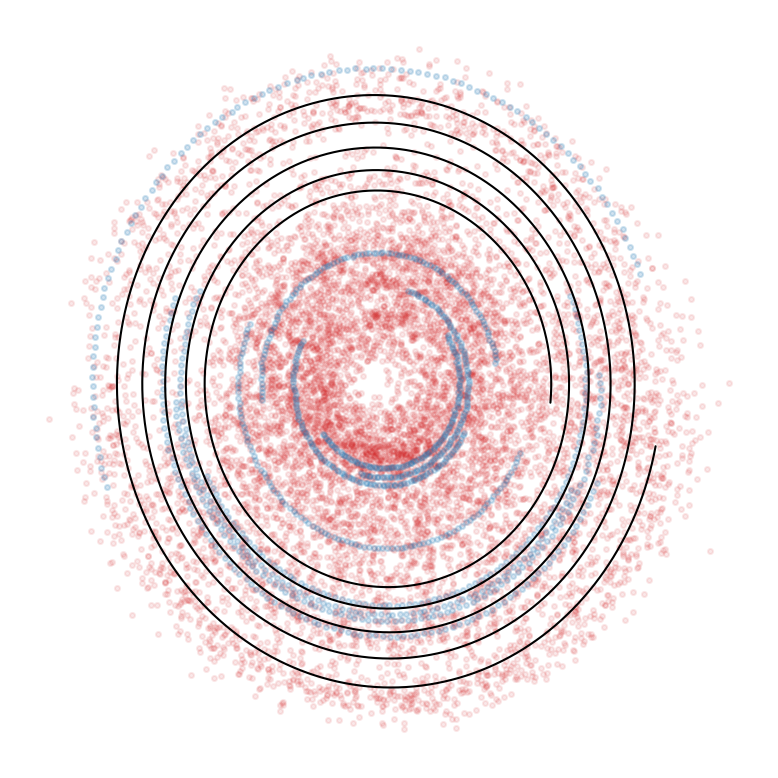

In [ ]:
# regenerate HF / LF datasets using the *absolute* noise levels from MF experiment
X_hf_noisy, t_train, _ = generate_pendulum_dataset(
    n_traj=cfg.n_hf,
    T=1,
    dt=cfg.dt,
    noise_level=noise_hf_abs,
    seed=cfg.seed_base,
)

X_lf_noisy, _, _ = generate_pendulum_dataset(
    n_traj=cfg.n_lf,
    T=1,
    dt=cfg.dt,
    noise_level=noise_lf_abs,
    seed=cfg.seed_base+100,
)

# long clean reference trajectory (no noise)
X_ref, _, _ = generate_pendulum_dataset(
    n_traj=1,
    T=10.0,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base+10,
)

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

# LF trajectories (noisy) – red
for X in X_lf_noisy:
    ax.plot(
        X[::10, 0],
        X[::10, 1],
        ".",
        color="tab:red",
        alpha=0.1,
        linewidth=0.6,
    )

# HF trajectories (noisy) – blue
for X in X_hf_noisy:
    ax.plot(
        X[::10, 0],
        X[::10, 1],
        ".",
        color="tab:blue",
        alpha=0.2,
        linewidth=0.8,
    )

# Clean reference trajectory – black
ax.plot(
    X_ref[0][:, 0],
    X_ref[0][:, 1],
    "-",
    color="black",
    alpha=1.0,
    linewidth=1.0,
)

# Remove ticks and spines for a clean, compact panel
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)

plt.tight_layout(pad=0.05)
plt.show()


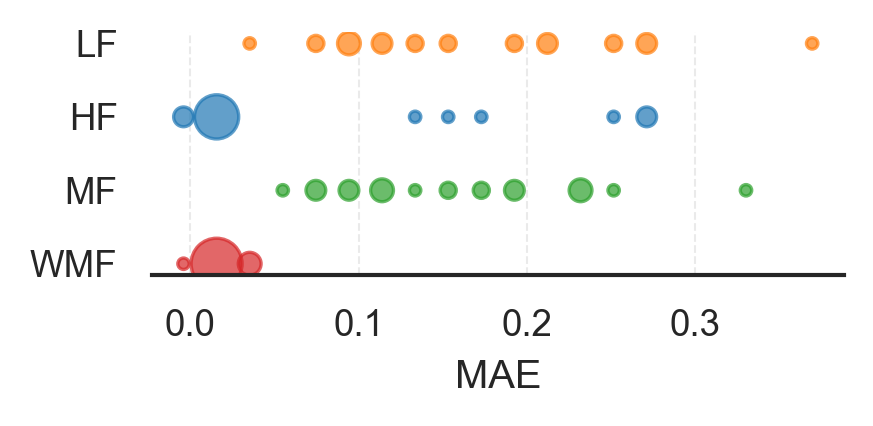

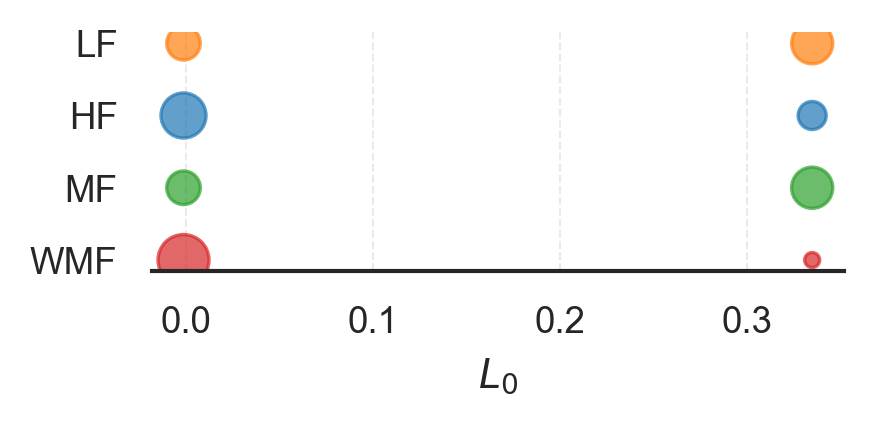

In [ ]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

